# Homework - Neural networks - Part C (25 points)
## A neural network model of semantic cognition

by *Brenden Lake*

In this assignment, you will help implement and analyze a neural network model of semantic cognition. Semantic cognition is our intuitive understanding of objects and their properties. Semantic knowledge includes observations of which objects have which properties, and storage of these facts in long term memory. It also includes the ability to generalize, or predict which properties apply to which objects although they have not been directly observed.

This notebook explores a neural network model of semantic cognition developed by Rogers and McClelland (R&M). R&M sought to model aspects of semantic cognition with a multi-layer neural network, which contrasts with classic symbolic approaches for organizing semantic knowledge. They model the cognitive development of semantic representation as gradient descent (the backpropagation algorithm), using a neural network trained to map objects to their corresponding properties. R&M also modeled the deterioration of semantic knowledge in dementia by adding noise to the learned representations.

The network architecture is illustrated below.

<br>
<img src="images/semcog_net.jpeg" style="width: 450px;"/>
<br><br>

There are two input layers ("Item Layer" and "Relation Layer"), which pass through intermediate layers to produce an output pattern on the "Attribute Layer." In this example, dark green is used to indicate active nodes (activation 1) and light green for inactive nodes (activation 0). The network is trained to answer queries involving an item (e.g., “Canary”) and a relation (e.g.,  “CAN”), outputting all attributes that are true of the item/relation pair (e.g., “grow, move, fly, sing”).

For this assignment, you will set up the network architecture in PyTorch and train it. The dataset and code for training has been provided. You will then analyze how its semantic knowledge develops of the course of training. While the original model used logistic (sigmoid) activation functions for all of the intermediate and output layers, we will use the ReLu activation for the Representation and Hidden Layers, with a sigmoid activation for the Attribute Layer.

Completing this assignment requires knowledge of setting up a neural network architecture in PyTorch. Please review your notes from lab and the following [PyTorch tutorial](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html).

<div class="alert alert-info">
Reference (available for download on Canvas):
    
McClelland, J. L., & Rogers, T. T. (2003). The parallel distributed processing approach to semantic cognition. Nature Reviews Neuroscience, 4(4), 310.
</div>

In [1]:
# Import libraries
from __future__ import print_function
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.nn.functional import sigmoid, relu
from scipy.cluster.hierarchy import dendrogram, linkage

Let's first load in the names of all the items, attributes, and relations into Python lists.

In [2]:
with open('data/sem_items.txt','r') as fid:
    names_items = np.array([l.strip() for l in fid.readlines()])
with open('data/sem_relations.txt','r') as fid:
    names_relations = np.array([l.strip() for l in fid.readlines()])
with open('data/sem_attributes.txt','r') as fid:
    names_attributes = np.array([l.strip() for l in fid.readlines()])
        
nobj = len(names_items)
nrel = len(names_relations)
nattributes = len(names_attributes)
print('List of items:')
print(names_items)
print("List of relations:")
print(names_relations)
print("List of attributes:")
print(names_attributes)

List of items:
['Pine' 'Oak' 'Rose' 'Daisy' 'Robin' 'Canary' 'Sunfish' 'Salmon']
List of relations:
['ISA' 'Is' 'Can' 'Has']
List of attributes:
['Living thing' 'Plant' 'Animal' 'Tree' 'Flower' 'Bird' 'Fish' 'Pine'
 'Oak' 'Rose' 'Daisy' 'Robin' 'Canary' 'Sunfish' 'Salmon' 'Pretty' 'Big'
 'Living' 'Green' 'Red' 'Yellow' 'Grow' 'Move' 'Swim' 'Fly' 'Sing' 'Skin'
 'Roots' 'Leaves' 'Bark' 'Branch' 'Petals' 'Wings' 'Feathers' 'Gills'
 'Scales']


Next, let's load in the data matrix from a text file too. The matrix `D` has a row for each training pattern. It is split into a matrix of input patterns `input_pats` (item and relation) and their corresponding output patterns `output_pats` (attributes). The are `N` patterns total in the set.

For each input pattern, the first 8 elements indicate which item is being presented, and the next 4 indicate which relation is being queried. Each element of the output pattern corresponds to a different attribute. All patterns use 1-hot encoding.

In [3]:
D = np.loadtxt('data/sem_data.txt')
input_pats = D[:,:nobj+nrel]
input_pats = torch.tensor(input_pats,dtype=torch.float)
output_pats = D[:,nobj+nrel:]
output_pats = torch.tensor(output_pats,dtype=torch.float)
N = input_pats.shape[0] # number of training patterns
input_v = input_pats[0,:].numpy().astype('bool')
output_v = output_pats[0,:].numpy().astype('bool')
print('Example input pattern:')
print(input_v.astype('int'))
print('Example output pattern:')
print(output_v.astype('int'))
print("")
print("Which encodes...")
print('Item ',end='')
print(names_items[input_v[:8]])
print('Relation ',end='')
print(names_relations[input_v[8:]])
print('Attributes ',end='')
print(names_attributes[output_v])

Example input pattern:
[1 0 0 0 0 0 0 0 1 0 0 0]
Example output pattern:
[1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Which encodes...
Item ['Pine']
Relation ['ISA']
Attributes ['Living thing' 'Plant' 'Tree' 'Pine']


<div class="alert alert-success" role="alert">
<h3> Problem 1 (20 points) </h3>
<br>
Your assignment is to create the neural network architecture shown in the figure above. Fill in the missing pieces of the "Net" class in the code below. For an example, refer to the PyTorch tutorial on <a href="https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html#sphx-glr-beginner-blitz-neural-networks-tutorial-py">"Neural Networks"</a>.
<br><br>
Use the ReLu activation function ("relu") for the Representation and Hidden Layers, with a Logistic/Sigmoid activation function for the Attribute Layer ("sigmoid").    
<br><br>
You will need PyTorch's "nn.Linear" function for constructing the layers, and the "relu" and "sigmoid" activation functions.
</div>

In [4]:
class Net(nn.Module):
    def __init__(self, rep_size, hidden_size):
        super(Net, self).__init__()
        # Input
        #  rep_size : number of hidden units in "Representation Layer"
        #  hidden_size : number of hidden units in "Hidden Layer"
        #
        # TODO : YOUR CODE GOES HERE
        self.i2rep = nn.Linear(nobj, rep_size)                         # item to representation
        self.repRel2hidden = nn.Linear(rep_size + nrel, hidden_size)   # [rep, relation] to hidden
        self.hidden2out = nn.Linear(hidden_size, nattributes)          # hidden to attribute

    def forward(self, x):
        # Defines forward pass for the network on input patterns x
        #
        # Input can take these two forms:
        #
        #   x: [nobj+nrel 1D Tensor], which is a single input pattern as a 1D tensor
        #      (containing both object and relation 1-hot identifier) (batch size is B=1)
        #   OR
        #   x : [B x (nobj+nrel) Tensor], which is a batch of B input patterns (one for each row)
        #
        # Output
        #   output [B x nattribute Tensor], which is the output pattern for each input pattern B on the Attribute Layer
        #   hidden [B x hidden_size Tensor], which are activations in the Hidden Layer
        #   rep [B x rep_size Tensor], which are the activations in the Representation Layer
        x = x.view(-1,nobj+nrel) # reshape as size [B x (nobj+nrel) Tensor] if B=1
        x_pat_item = x[:,:nobj] # input to Item Layer [B x nobj Tensor]
        x_pat_rel = x[:,nobj:] # input to Relation Layer [B x nrel Tensor]
        # TODO : YOUR CODE GOES HERE
        # ----
        rep = relu(self.i2rep(x_pat_item))
        hidden = relu(self.repRel2hidden(torch.cat((rep, x_pat_rel), dim=1)))
        output = sigmoid(self.hidden2out(hidden))
        # -----
        return output, hidden, rep


We provide a completed function `train` for stochastic gradient descent. The network makes online (rather than batch) updates, adjusting its weights after the presentation of each input pattern.

In [5]:
def train(mynet,epoch_count,nepochs_additional=5000):
    # Input
    #  mynet : Net class object
    #  epoch_count : (scalar) how many epochs have been completed so far
    #  nepochs_additional : (scalar) how many more epochs we want to run
    mynet.train()
    for e in range(nepochs_additional): # for each epoch
        error_epoch = 0.
        perm = np.random.permutation(N)
        for p in perm: # iterate through input patterns in random order
            mynet.zero_grad() # reset gradient
            output, hidden, rep = mynet(input_pats[p,:]) # forward pass
            target = output_pats[p,:] 
            loss = criterion(output, target) # compute loss
            loss.backward() # compute gradient 
            optimizer.step() # update network parameters
            error_epoch += loss.item()
        error_epoch = error_epoch / float(N)        
        if e % 50 == 0:
            print('epoch ' + str(epoch_count+e) + ' loss ' + str(round(error_epoch,3)))
    return epoch_count + nepochs_additional

We provide some useful functions for extracting the activation pattern on the Representation Layer for each possible item. We provide two functions `plot_rep` and `plot_dendo` for visualizing these activation patterns.

In [6]:
def get_rep(net):
    # Extract the hidden activations on the Representation Layer for each item
    # 
    # Input
    #  net : Net class object
    #
    # Output
    #  rep : [nitem x rep_size numpy array], where each row is an item
    input_clean = torch.zeros(nobj,nobj+nrel)
    for idx,name in enumerate(names_items):
        input_clean[idx,idx] = 1. # 1-hot encoding of each object (while Relation Layer doesn't matter)
    output, hidden, rep = mynet(input_clean)
    return rep.detach().numpy()

def plot_rep(rep1,rep2,rep3,names):
    #  Compares Representation Layer activations of Items at three different times points in learning (rep1, rep2, rep3)
    #  using bar graphs
    # 
    #  Each rep1, rep2, rep3 is a [nitem x rep_size numpy array]
    #  names : [nitem list] of item names
    #
    nepochs_list = [nepochs_phase1,nepochs_phase2,nepochs_phase3]
    nrows = nobj
    R = np.dstack((rep1,rep2,rep3))    
    mx = R.max()
    mn = R.min()
    depth = R.shape[2]
    count = 1
    plt.figure(1,figsize=(4.2,8.4))
    for i in range(nrows):
        for d in range(R.shape[2]):
            plt.subplot(nrows, depth, count)
            rep = R[i,:,d]
            plt.bar(range(rep.size),rep)
            plt.ylim([mn,mx])
            plt.xticks([])
            plt.yticks([])        
            if d==0:
                plt.ylabel(names[i])
            if i==0:
                plt.title("epoch " + str(nepochs_list[d]))
            count += 1
    plt.show()

def plot_dendo(rep1,rep2,rep3,names):
    #  Compares Representation Layer activations of Items at three different times points in learning (rep1, rep2, rep3)
    #  using hierarchical clustering
    # 
    #  Each rep1, rep2, rep3 is a [nitem x rep_size numpy array]
    #  names : [nitem list] of item names
    #
    nepochs_list = [nepochs_phase1,nepochs_phase2,nepochs_phase3]
    linked1 = linkage(rep1,'single')
    linked2 = linkage(rep2,'single')
    linked3 = linkage(rep3,'single')
    mx = np.dstack((linked1[:,2],linked2[:,2],linked3[:,2])).max()+0.1    
    plt.figure(2,figsize=(7,12))
    plt.subplot(3,1,1)    
    dendrogram(linked1, labels=names, color_threshold=0)
    plt.ylim([0,mx])
    plt.title('Hierarchical clustering; ' + "epoch " + str(nepochs_list[0]))
    plt.ylabel('Euclidean distance')
    plt.subplot(3,1,2)
    plt.title("epoch " + str(nepochs_list[1]))
    dendrogram(linked2, labels=names, color_threshold=0)
    plt.ylim([0,mx])
    plt.subplot(3,1,3)
    plt.title("epoch " + str(nepochs_list[2]))
    dendrogram(linked3, labels=names, color_threshold=0)
    plt.ylim([0,mx])
    plt.show()

The next script initializes the neural network and trains it for 2500 epochs total. It trains in three stages, and the item representations (on the Representation Layer) are extracted after 500 epochs, 1000 epochs, and then at the end of training (2500 epochs).

In [7]:
learning_rate = 0.1
criterion = nn.MSELoss() # mean squared error loss function
mynet = Net(rep_size=8,hidden_size=15)
optimizer = torch.optim.SGD(mynet.parameters(), lr=learning_rate) # stochastic gradient descent

nepochs_phase1 = 500
nepochs_phase2 = 1000
nepochs_phase3 = 2500
epoch_count = 0
epoch_count = train(mynet,epoch_count,nepochs_additional=nepochs_phase1)
rep1 = get_rep(mynet)
epoch_count = train(mynet,epoch_count,nepochs_additional=nepochs_phase2-nepochs_phase1)
rep2 = get_rep(mynet)
epoch_count = train(mynet,epoch_count,nepochs_additional=nepochs_phase3-nepochs_phase2)
rep3 = get_rep(mynet)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([36])) that is different to the input size (torch.Size([1, 36])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch 0 loss 0.248
epoch 50 loss 0.071
epoch 100 loss 0.068
epoch 150 loss 0.064
epoch 200 loss 0.059
epoch 250 loss 0.055
epoch 300 loss 0.051
epoch 350 loss 0.048
epoch 400 loss 0.046
epoch 450 loss 0.045
epoch 500 loss 0.044
epoch 550 loss 0.043
epoch 600 loss 0.041
epoch 650 loss 0.04
epoch 700 loss 0.038
epoch 750 loss 0.033
epoch 800 loss 0.029
epoch 850 loss 0.026
epoch 900 loss 0.024
epoch 950 loss 0.022
epoch 1000 loss 0.021
epoch 1050 loss 0.02
epoch 1100 loss 0.018
epoch 1150 loss 0.017
epoch 1200 loss 0.015
epoch 1250 loss 0.014
epoch 1300 loss 0.013
epoch 1350 loss 0.011
epoch 1400 loss 0.01
epoch 1450 loss 0.009
epoch 1500 loss 0.009
epoch 1550 loss 0.008
epoch 1600 loss 0.007
epoch 1650 loss 0.007
epoch 1700 loss 0.006
epoch 1750 loss 0.005
epoch 1800 loss 0.005
epoch 1850 loss 0.004
epoch 1900 loss 0.004
epoch 1950 loss 0.004
epoch 2000 loss 0.003
epoch 2050 loss 0.003
epoch 2100 loss 0.002
epoch 2150 loss 0.002
epoch 2200 loss 0.002
epoch 2250 loss 0.002
epoch 2300 los

Finally, let's visualize the Representation Layer at the different stages of learning.

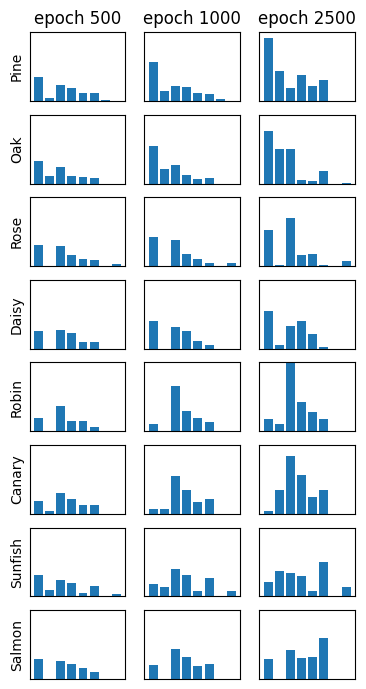

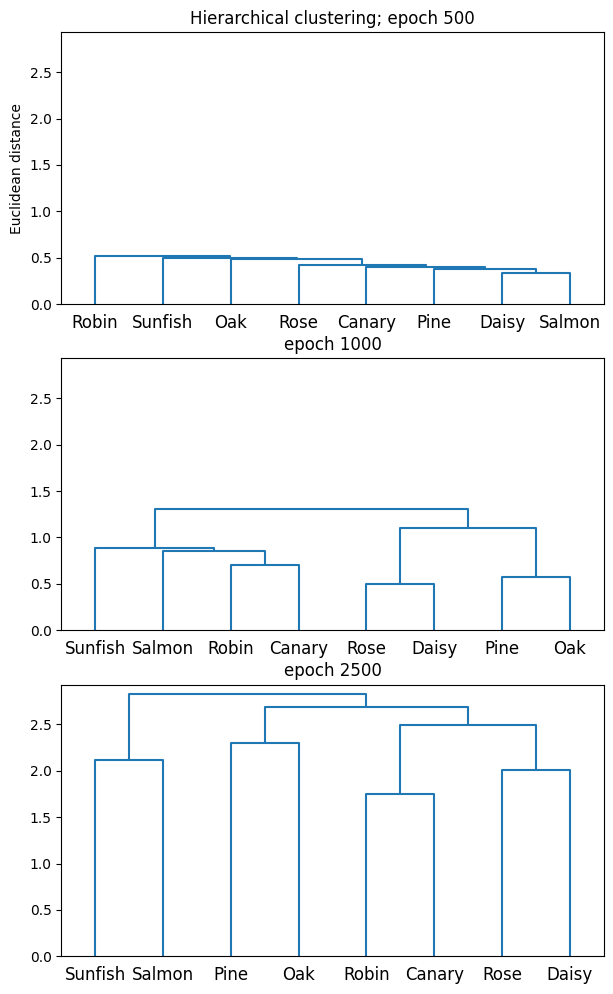

In [8]:
plot_rep(rep1,rep2,rep3,names_items)
plot_dendo(rep1,rep2,rep3,names_items)

<div class="alert alert-success" role="alert">
<h3> Problem 2 (5 points) </h3>
<br>
Based on your plots, write a short analysis (4-5 sentences) of how the internal representations of the network develop over the course of learning. How does learning progress? Does the network start by differentiating certain classes of patterns from each other, and then differentiate others in later stages?
</div>

<div class="alert alert-info">
Hint: You can refer to your lecture slides and notes for the R&M model for help with your analysis. Your network should broadly replicate their findings, but since the training patterns and activation function aren't identical, don't expect the exact same results.
</div>

**Answer:** Early in training (epoch 500), the network already splits plants from animals, but all distances are small (under 0.7), so this is only a rough distinction and items within each group look very similar. By epoch 1000, the plant vs. animal split is much clearer (around 1.8), and within the animals the birds (robin and canary) have started to pair up, but finer plant groups have not formed yet. By epoch 2500, the distances are much larger (about 2.0 or more) and the network has learned the specific classes: trees (pine and oak), flowers (rose and daisy), fish, and birds each form their own pair. Overall, learning moves from broad to specific, which matches Rogers and McClelland's idea of progressive differentiation, because attributes shared by many items (like those shared by all animals) give large, consistent error signals early, while item-specific attributes are learned later. One difference from R&M is that in the final dendrogram the flowers join the animals before joining the trees, likely because of the ReLU activations and the random starting weights.